# 04. Predictive Maintenance Optimization

## Objective

This notebook translates the machine-learning failure-risk model into operational decision support.

The primary objective is to identify operating conditions that minimize predicted machine-failure risk while maintaining feasible production requirements.

The optimization stage uses the final Gradient Boosting model selected and validated in the machine-learning analysis.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import joblib

In [2]:
final_model = joblib.load(
    "../models/final_gradient_boosting_model.pkl"
)

feature_set = joblib.load(
    "../models/final_feature_set.pkl"
)

final_threshold = joblib.load(
    "../models/final_threshold.pkl"
)

print("Threshold:", final_threshold)
print("Features:", feature_set)

Threshold: 0.65
Features: ['Type', 'Air temperature [K]', 'Process temperature [K]', 'Rotational speed [rpm]', 'Torque [Nm]', 'Tool wear [min]', 'Temperature difference [K]', 'Mechanical power [kW]', 'Torque_SPC_Alarm', 'Power_SPC_Alarm', 'RPM_SPC_Alarm']


In [3]:
df = pd.read_csv(
    "../data/processed/ai4i2020_features.csv"
)

df.head()

,UDI,Product ID,Type,Air temperature [K],Process temperature [K],Rotational speed [rpm],Torque [Nm],Tool wear [min],Machine failure,TWF,HDF,PWF,OSF,RNF,Temperature difference [K],Mechanical power [kW]
0,1,M14860,M,298.1,308.6,1551,42.8,0,0,0,0,0,0,0,10.5,6.951591
1,2,L47181,L,298.2,308.7,1408,46.3,3,0,0,0,0,0,0,10.5,6.826723
2,3,L47182,L,298.1,308.5,1498,49.4,5,0,0,0,0,0,0,10.4,7.749388
3,4,L47183,L,298.2,308.6,1433,39.5,7,0,0,0,0,0,0,10.4,5.927505
4,5,L47184,L,298.2,308.7,1408,40.0,9,0,0,0,0,0,0,10.5,5.897817


In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import joblib

final_model = joblib.load(
    "../models/final_gradient_boosting_model.pkl"
)

feature_set = joblib.load(
    "../models/final_feature_set.pkl"
)

final_threshold = joblib.load(
    "../models/final_threshold.pkl"
)

df = pd.read_csv(
    "../data/processed/ai4i2020_features.csv"
)

print("Final threshold:", final_threshold)
print("\nModel features:")
print(feature_set)

print("\nDataset shape:", df.shape)

Final threshold: 0.65

Model features:
['Type', 'Air temperature [K]', 'Process temperature [K]', 'Rotational speed [rpm]', 'Torque [Nm]', 'Tool wear [min]', 'Temperature difference [K]', 'Mechanical power [kW]', 'Torque_SPC_Alarm', 'Power_SPC_Alarm', 'RPM_SPC_Alarm']

Dataset shape: (10000, 16)


In [5]:
train_df = df.iloc[:7000].copy()

print("Train:", train_df.shape)

Train: (7000, 16)


In [6]:
rpm_low = train_df["Rotational speed [rpm]"].quantile(0.05)
rpm_high = train_df["Rotational speed [rpm]"].quantile(0.95)

torque_low = train_df["Torque [Nm]"].quantile(0.05)
torque_high = train_df["Torque [Nm]"].quantile(0.95)

power_median = train_df["Mechanical power [kW]"].median()

print(f"RPM range: {rpm_low:.1f} ~ {rpm_high:.1f}")
print(f"Torque range: {torque_low:.2f} ~ {torque_high:.2f}")
print(f"Scenario minimum power: {power_median:.3f} kW")

RPM range: 1331.0 ~ 1880.0
Torque range: 23.10 ~ 55.90
Scenario minimum power: 6.266 kW


In [7]:
base_air_temp = train_df["Air temperature [K]"].median()
base_process_temp = train_df["Process temperature [K]"].median()
base_tool_wear = train_df["Tool wear [min]"].median()
base_type = train_df["Type"].mode()[0]

base_temp_diff = (
    base_process_temp - base_air_temp
)

print("Air temperature:", base_air_temp)
print("Process temperature:", base_process_temp)
print("Tool wear:", base_tool_wear)
print("Type:", base_type)
print("Temperature difference:", base_temp_diff)

Air temperature: 300.7
Process temperature: 310.1
Tool wear: 109.0
Type: L
Temperature difference: 9.400000000000034


In [8]:
rpm_grid = np.linspace(
    rpm_low,
    rpm_high,
    60
)

torque_grid = np.linspace(
    torque_low,
    torque_high,
    60
)

candidate_rows = []

for rpm in rpm_grid:
    for torque in torque_grid:

        power = (
            2 * np.pi
            * rpm
            * torque
            / 60
            / 1000
        )

        candidate_rows.append({
            "Air temperature [K]": base_air_temp,
            "Process temperature [K]": base_process_temp,
            "Rotational speed [rpm]": rpm,
            "Torque [Nm]": torque,
            "Tool wear [min]": base_tool_wear,
            "Temperature difference [K]": base_temp_diff,
            "Mechanical power [kW]": power,
            "Type": base_type
        })

optimization_candidates = pd.DataFrame(
    candidate_rows
)

optimization_candidates.shape

(3600, 8)

In [9]:
missing_features = [
    feature
    for feature in feature_set
    if feature not in optimization_candidates.columns
]

print("Missing features:", missing_features)

Missing features: ['Torque_SPC_Alarm', 'Power_SPC_Alarm', 'RPM_SPC_Alarm']


In [11]:
# Reconstruct SPC control limits from training data

d2 = 1.128   # Moving range of size 2

def calculate_i_chart_limits(series):
    series = series.dropna()

    center = series.mean()

    moving_range = series.diff().abs().dropna()
    mr_mean = moving_range.mean()

    sigma_est = mr_mean / d2

    ucl = center + 3 * sigma_est
    lcl = center - 3 * sigma_est

    return {
        "Center": center,
        "LCL": lcl,
        "UCL": ucl
    }


torque_limits = calculate_i_chart_limits(
    train_df["Torque [Nm]"]
)

power_limits = calculate_i_chart_limits(
    train_df["Mechanical power [kW]"]
)

rpm_limits = calculate_i_chart_limits(
    train_df["Rotational speed [rpm]"]
)


sqc_limits = {
    "Torque_LCL": torque_limits["LCL"],
    "Torque_UCL": torque_limits["UCL"],

    "Power_LCL": power_limits["LCL"],
    "Power_UCL": power_limits["UCL"],

    "RPM_LCL": rpm_limits["LCL"],
    "RPM_UCL": rpm_limits["UCL"]
}

sqc_limits

{'Torque_LCL': np.float64(10.060476718992856),
 'Torque_UCL': np.float64(69.79066613815),
 'Power_LCL': np.float64(3.0829220345632624),
 'Power_UCL': np.float64(9.462362168017115),
 'RPM_LCL': np.float64(1051.9791477575388),
 'RPM_UCL': np.float64(2029.1871379567467)}

In [12]:
joblib.dump(
    sqc_limits,
    "../models/sqc_limits.pkl"
)

print("SQC limits saved.")

SQC limits saved.


In [13]:
rpm_low = train_df["Rotational speed [rpm]"].quantile(0.05)
rpm_high = train_df["Rotational speed [rpm]"].quantile(0.95)

torque_low = train_df["Torque [Nm]"].quantile(0.05)
torque_high = train_df["Torque [Nm]"].quantile(0.95)

power_median = train_df["Mechanical power [kW]"].median()

print(f"RPM range: {rpm_low:.1f} ~ {rpm_high:.1f}")
print(f"Torque range: {torque_low:.2f} ~ {torque_high:.2f}")
print(f"Minimum required power: {power_median:.3f} kW")

RPM range: 1331.0 ~ 1880.0
Torque range: 23.10 ~ 55.90
Minimum required power: 6.266 kW


In [14]:
base_air_temp = train_df["Air temperature [K]"].median()
base_process_temp = train_df["Process temperature [K]"].median()
base_tool_wear = train_df["Tool wear [min]"].median()
base_type = train_df["Type"].mode()[0]

base_temp_diff = (
    base_process_temp - base_air_temp
)

print("Air temperature:", base_air_temp)
print("Process temperature:", base_process_temp)
print("Tool wear:", base_tool_wear)
print("Type:", base_type)
print("Temperature difference:", base_temp_diff)

Air temperature: 300.7
Process temperature: 310.1
Tool wear: 109.0
Type: L
Temperature difference: 9.400000000000034


In [15]:
rpm_grid = np.linspace(
    rpm_low,
    rpm_high,
    60
)

torque_grid = np.linspace(
    torque_low,
    torque_high,
    60
)

candidate_rows = []

for rpm in rpm_grid:
    for torque in torque_grid:

        mechanical_power = (
            2 * np.pi
            * rpm
            * torque
            / 60
            / 1000
        )

        candidate_rows.append({
            "Air temperature [K]": base_air_temp,
            "Process temperature [K]": base_process_temp,
            "Rotational speed [rpm]": rpm,
            "Torque [Nm]": torque,
            "Tool wear [min]": base_tool_wear,
            "Temperature difference [K]": base_temp_diff,
            "Mechanical power [kW]": mechanical_power,
            "Type": base_type
        })

optimization_candidates = pd.DataFrame(candidate_rows)

print(optimization_candidates.shape)
optimization_candidates.head()

(3600, 8)


,Air temperature [K],Process temperature [K],Rotational speed [rpm],Torque [Nm],Tool wear [min],Temperature difference [K],Mechanical power [kW],Type
0,300.7,310.1,1331.0,23.100000,109.0,9.4,3.219724,L
1,300.7,310.1,1331.0,23.655932,109.0,9.4,3.297211,L
2,300.7,310.1,1331.0,24.211864,109.0,9.4,3.374698,L
3,300.7,310.1,1331.0,24.767797,109.0,9.4,3.452185,L
4,300.7,310.1,1331.0,25.323729,109.0,9.4,3.529672,L


In [16]:
optimization_candidates["Torque_SPC_Alarm"] = (
    (
        optimization_candidates["Torque [Nm]"]
        < sqc_limits["Torque_LCL"]
    )
    |
    (
        optimization_candidates["Torque [Nm]"]
        > sqc_limits["Torque_UCL"]
    )
).astype(int)

optimization_candidates["Power_SPC_Alarm"] = (
    (
        optimization_candidates["Mechanical power [kW]"]
        < sqc_limits["Power_LCL"]
    )
    |
    (
        optimization_candidates["Mechanical power [kW]"]
        > sqc_limits["Power_UCL"]
    )
).astype(int)

optimization_candidates["RPM_SPC_Alarm"] = (
    (
        optimization_candidates["Rotational speed [rpm]"]
        < sqc_limits["RPM_LCL"]
    )
    |
    (
        optimization_candidates["Rotational speed [rpm]"]
        > sqc_limits["RPM_UCL"]
    )
).astype(int)

In [17]:
missing_features = [
    col for col in feature_set
    if col not in optimization_candidates.columns
]

print("Missing features:", missing_features)

Missing features: []


In [18]:
feasible_candidates = optimization_candidates[
    optimization_candidates["Mechanical power [kW]"]
    >= power_median
].copy()

print(
    "All candidates:",
    len(optimization_candidates)
)

print(
    "Feasible candidates:",
    len(feasible_candidates)
)

All candidates: 3600
Feasible candidates: 1999


In [19]:
feasible_candidates["Predicted_Failure_Risk"] = (
    final_model.predict_proba(
        feasible_candidates[feature_set]
    )[:, 1]
)

In [20]:
optimal_points = (
    feasible_candidates
    .sort_values(
        "Predicted_Failure_Risk",
        ascending=True
    )
    .head(10)
)

optimal_points[
    [
        "Rotational speed [rpm]",
        "Torque [Nm]",
        "Mechanical power [kW]",
        "Tool wear [min]",
        "Torque_SPC_Alarm",
        "Power_SPC_Alarm",
        "RPM_SPC_Alarm",
        "Predicted_Failure_Risk"
    ]
].round(4)

,Rotational speed [rpm],Torque [Nm],Mechanical power [kW],Tool wear [min],Torque_SPC_Alarm,Power_SPC_Alarm,RPM_SPC_Alarm,Predicted_Failure_Risk
2853,1768.3390,41.4458,7.6749,109.0,0,0,0,0.013
3269,1833.4746,39.2220,7.5307,109.0,0,0,0,0.013
3270,1833.4746,39.7780,7.6374,109.0,0,0,0,0.013
2732,1749.7288,40.8898,7.4923,109.0,0,0,0,0.013
2733,1749.7288,41.4458,7.5942,109.0,0,0,0,0.013
2734,1749.7288,42.0017,7.6960,109.0,0,0,0,0.013
3449,1861.3898,39.2220,7.6453,109.0,0,0,0,0.013
3149,1814.8644,39.2220,7.4542,109.0,0,0,0,0.013
3150,1814.8644,39.7780,7.5599,109.0,0,0,0,0.013
3151,1814.8644,40.3339,7.6655,109.0,0,0,0,0.013


In [21]:
best_point = optimal_points.iloc[0]

print("=== Optimal Operating Point ===")
print(
    f"RPM: {best_point['Rotational speed [rpm]']:.2f}"
)
print(
    f"Torque: {best_point['Torque [Nm]']:.2f} Nm"
)
print(
    f"Mechanical Power: {best_point['Mechanical power [kW]']:.3f} kW"
)
print(
    f"Predicted Failure Risk: "
    f"{best_point['Predicted_Failure_Risk'] * 100:.2f}%"
)

=== Optimal Operating Point ===
RPM: 1768.34
Torque: 41.45 Nm
Mechanical Power: 7.675 kW
Predicted Failure Risk: 1.30%


In [22]:
# Predict failure risk for ALL candidate operating points

optimization_candidates["Predicted_Failure_Risk"] = (
    final_model.predict_proba(
        optimization_candidates[feature_set]
    )[:, 1]
)

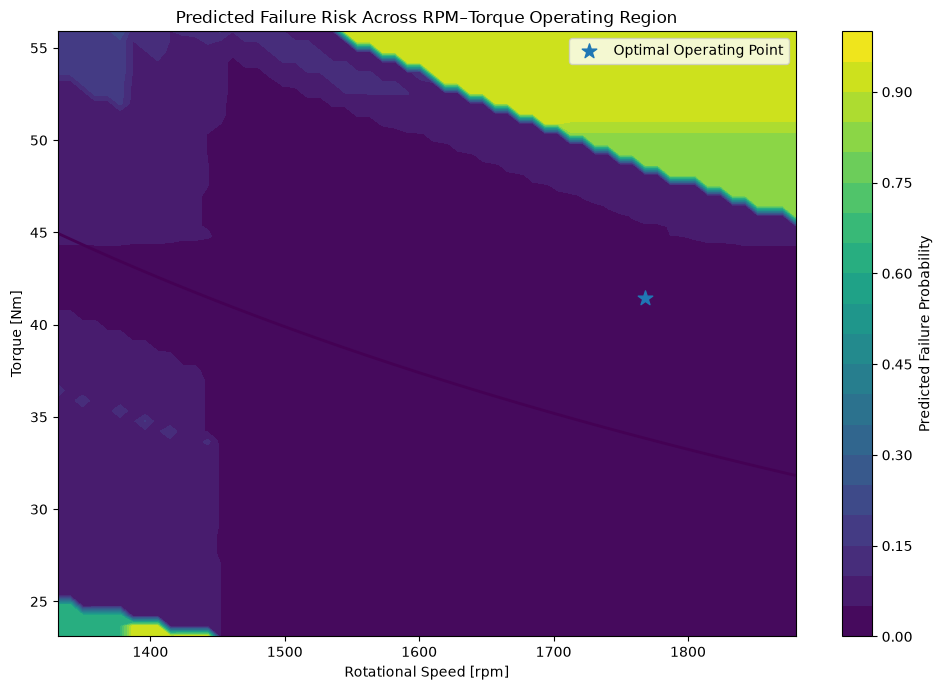

In [23]:
import os

os.makedirs("../figures/optimization", exist_ok=True)

risk_grid = (
    optimization_candidates["Predicted_Failure_Risk"]
    .values
    .reshape(len(rpm_grid), len(torque_grid))
)

power_grid = (
    optimization_candidates["Mechanical power [kW]"]
    .values
    .reshape(len(rpm_grid), len(torque_grid))
)

RPM_mesh, Torque_mesh = np.meshgrid(
    rpm_grid,
    torque_grid,
    indexing="ij"
)

plt.figure(figsize=(10, 7))

contour = plt.contourf(
    RPM_mesh,
    Torque_mesh,
    risk_grid,
    levels=20
)

plt.colorbar(
    contour,
    label="Predicted Failure Probability"
)

# Minimum required power boundary
plt.contour(
    RPM_mesh,
    Torque_mesh,
    power_grid,
    levels=[power_median],
    linewidths=2
)

# Best operating point
plt.scatter(
    best_point["Rotational speed [rpm]"],
    best_point["Torque [Nm]"],
    s=120,
    marker="*",
    label="Optimal Operating Point"
)

plt.xlabel("Rotational Speed [rpm]")
plt.ylabel("Torque [Nm]")
plt.title(
    "Predicted Failure Risk Across RPM–Torque Operating Region"
)

plt.legend()

plt.tight_layout()

plt.savefig(
    "../figures/optimization/"
    "rpm_torque_failure_risk_surface.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [24]:
# Regime A = safest feasible operating point
regime_A = feasible_candidates.sort_values(
    "Predicted_Failure_Risk"
).iloc[0]

# Regime B = high-output / relatively high-risk operating condition

power_q80 = feasible_candidates[
    "Mechanical power [kW]"
].quantile(0.80)

risk_q75 = feasible_candidates[
    "Predicted_Failure_Risk"
].quantile(0.75)

regime_B_pool = feasible_candidates[
    (
        feasible_candidates["Mechanical power [kW]"]
        >= power_q80
    )
    &
    (
        feasible_candidates["Predicted_Failure_Risk"]
        >= risk_q75
    )
]

regime_B = (
    regime_B_pool
    .sort_values(
        "Mechanical power [kW]",
        ascending=False
    )
    .iloc[0]
)

regime_comparison = pd.DataFrame({
    "Safe Regime A": [
        regime_A["Rotational speed [rpm]"],
        regime_A["Torque [Nm]"],
        regime_A["Mechanical power [kW]"],
        regime_A["Predicted_Failure_Risk"]
    ],
    "High-output Regime B": [
        regime_B["Rotational speed [rpm]"],
        regime_B["Torque [Nm]"],
        regime_B["Mechanical power [kW]"],
        regime_B["Predicted_Failure_Risk"]
    ]
}, index=[
    "RPM",
    "Torque",
    "Mechanical Power",
    "Predicted Failure Risk"
])

regime_comparison.round(4)

,Safe Regime A,High-output Regime B
RPM,1768.3390,1880.0000
Torque,41.4458,55.9000
Mechanical Power,7.6749,11.0052
Predicted Failure Risk,0.0130,0.9264


In [25]:
shift_hours = 8

power_A = regime_A["Mechanical power [kW]"]
power_B = regime_B["Mechanical power [kW]"]

risk_A = regime_A["Predicted_Failure_Risk"]
risk_B = regime_B["Predicted_Failure_Risk"]

risk_budget = shift_hours * (
    0.60 * risk_A
    +
    0.40 * risk_B
)

print("Power A:", power_A)
print("Power B:", power_B)

print("Risk A:", risk_A)
print("Risk B:", risk_B)

print("Risk budget:", risk_budget)

Power A: 7.674927386468044
Power B: 11.005208505035286
Risk A: 0.01304550747130895
Risk B: 0.9263506964569667
Risk budget: 3.0269406645245764


In [26]:
from scipy.optimize import linprog

In [27]:
c = [
    -power_A,
    -power_B
]

A_ub = [
    [1, 1],
    [risk_A, risk_B]
]

b_ub = [
    shift_hours,
    risk_budget
]

bounds = [
    (0, None),
    (0, None)
]

lp_result = linprog(
    c=c,
    A_ub=A_ub,
    b_ub=b_ub,
    bounds=bounds,
    method="highs"
)

x1_opt, x2_opt = lp_result.x

max_output = -lp_result.fun

print("=== Simplex / LP Optimal Solution ===")
print(f"Safe Regime A hours: {x1_opt:.3f}")
print(f"High-output Regime B hours: {x2_opt:.3f}")
print(f"Maximum output score: {max_output:.3f}")

=== Simplex / LP Optimal Solution ===
Safe Regime A hours: 4.800
High-output Regime B hours: 3.200
Maximum output score: 72.056


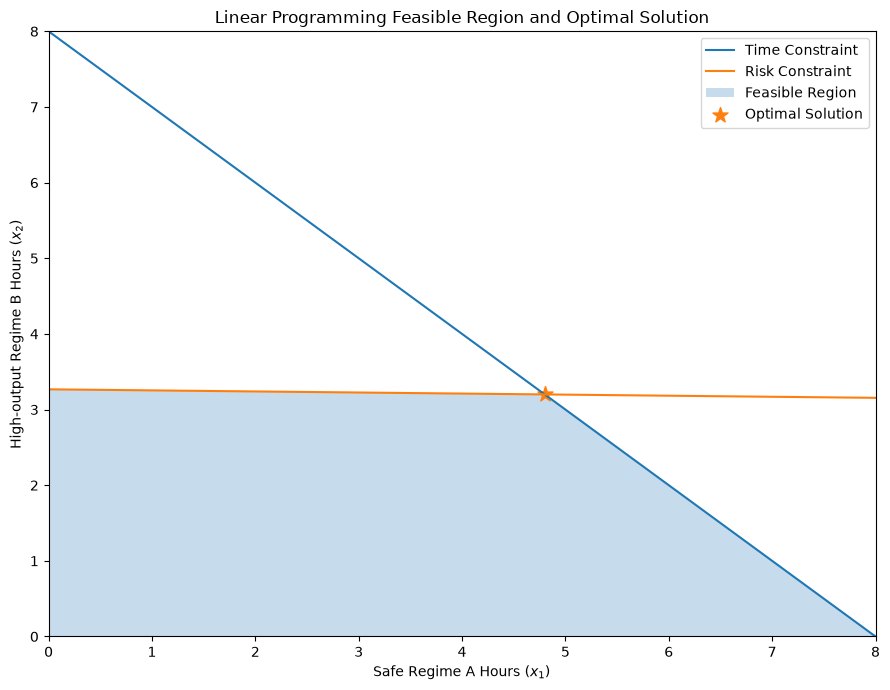

In [28]:
x1_values = np.linspace(
    0,
    shift_hours,
    500
)

# Constraint 1
# x1 + x2 <= 8

time_boundary = (
    shift_hours - x1_values
)

# Constraint 2
# risk_A*x1 + risk_B*x2 <= risk_budget

risk_boundary = (
    risk_budget
    - risk_A * x1_values
) / risk_B

# Feasible upper boundary

feasible_upper = np.minimum(
    time_boundary,
    risk_boundary
)

feasible_upper = np.maximum(
    feasible_upper,
    0
)

plt.figure(figsize=(9, 7))

plt.plot(
    x1_values,
    time_boundary,
    label="Time Constraint"
)

plt.plot(
    x1_values,
    risk_boundary,
    label="Risk Constraint"
)

plt.fill_between(
    x1_values,
    0,
    feasible_upper,
    alpha=0.25,
    label="Feasible Region"
)

plt.scatter(
    x1_opt,
    x2_opt,
    s=130,
    marker="*",
    label="Optimal Solution"
)

plt.xlabel("Safe Regime A Hours ($x_1$)")
plt.ylabel("High-output Regime B Hours ($x_2$)")

plt.xlim(0, shift_hours)
plt.ylim(0, shift_hours)

plt.title(
    "Linear Programming Feasible Region and Optimal Solution"
)

plt.legend()

plt.tight_layout()

plt.savefig(
    "../figures/optimization/"
    "simplex_feasible_region.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

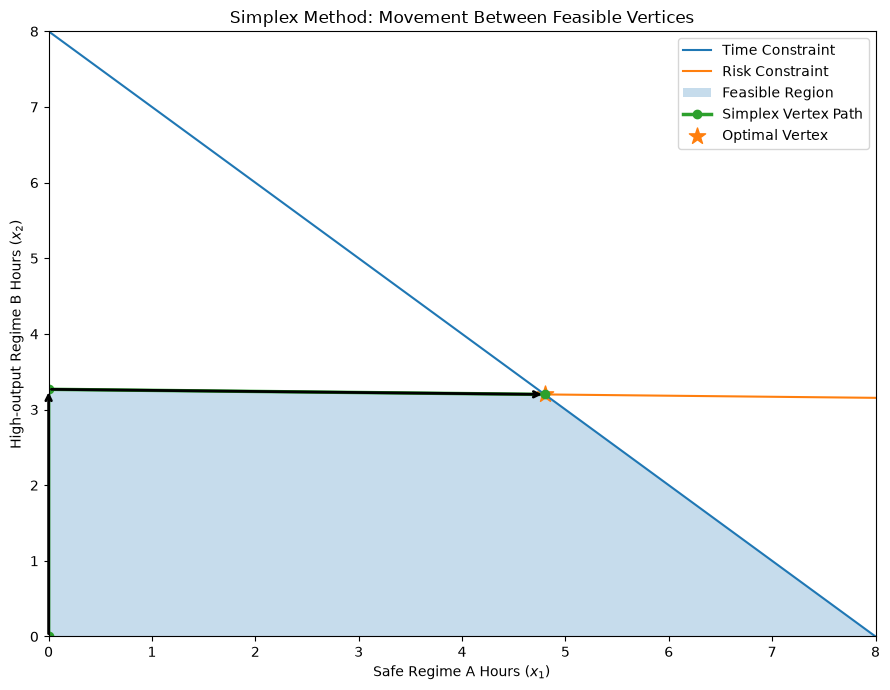

In [29]:
x2_axis_vertex = min(
    shift_hours,
    risk_budget / risk_B
)

simplex_path = np.array([
    [0, 0],
    [0, x2_axis_vertex],
    [x1_opt, x2_opt]
])

plt.figure(figsize=(9, 7))

plt.plot(
    x1_values,
    time_boundary,
    label="Time Constraint"
)

plt.plot(
    x1_values,
    risk_boundary,
    label="Risk Constraint"
)

plt.fill_between(
    x1_values,
    0,
    feasible_upper,
    alpha=0.25,
    label="Feasible Region"
)

# Simplex path
plt.plot(
    simplex_path[:, 0],
    simplex_path[:, 1],
    marker="o",
    linewidth=2.5,
    label="Simplex Vertex Path"
)

# Direction arrows
for i in range(len(simplex_path) - 1):

    start = simplex_path[i]
    end = simplex_path[i + 1]

    plt.annotate(
        "",
        xy=end,
        xytext=start,
        arrowprops=dict(
            arrowstyle="->",
            lw=2
        )
    )

plt.scatter(
    x1_opt,
    x2_opt,
    s=150,
    marker="*",
    label="Optimal Vertex"
)

plt.xlabel("Safe Regime A Hours ($x_1$)")
plt.ylabel("High-output Regime B Hours ($x_2$)")

plt.xlim(0, shift_hours)
plt.ylim(0, shift_hours)

plt.title(
    "Simplex Method: Movement Between Feasible Vertices"
)

plt.legend()

plt.tight_layout()

plt.savefig(
    "../figures/optimization/"
    "simplex_vertex_path.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

## Optimization Framework

The optimization stage was divided into two complementary decision problems.

### Operating-Condition Optimization

The validated Gradient Boosting model was used as a surrogate risk model to estimate failure probability across combinations of rotational speed and torque.

The primary optimization objective was:

\[
\min P(\text{Machine Failure})
\]

subject to a minimum mechanical-power requirement and operating ranges derived from the observed training data.

Because the Gradient Boosting prediction function and mechanical-power relationship are nonlinear, this problem was evaluated using a constrained grid-search approach rather than linear programming.

### Linear Programming Extension

A second decision problem was formulated to demonstrate operational resource allocation using linear programming.

Two representative operating regimes were defined:

- a low-risk operating regime;
- a high-output operating regime.

The decision variables represent the number of operating hours allocated to each regime during an eight-hour shift.

The objective is to maximize total mechanical output:

\[
\max Z=P_Ax_1+P_Bx_2
\]

subject to:

\[
x_1+x_2\le8
\]

and a scenario-based cumulative risk-exposure constraint:

\[
r_Ax_1+r_Bx_2\le R_{max}
\]

The resulting linear program can be solved using the simplex principle, in which the solution progresses between feasible vertices until the objective cannot be further improved.

The risk-exposure constraint is a scenario-based decision-support metric and should not be interpreted as a literal cumulative probability of machine failure.

In [30]:
tool_wear_scenarios = {
    "Low Wear": train_df["Tool wear [min]"].quantile(0.25),
    "Medium Wear": train_df["Tool wear [min]"].quantile(0.50),
    "High Wear": train_df["Tool wear [min]"].quantile(0.75)
}

tool_wear_scenarios

{'Low Wear': np.float64(53.0),
 'Medium Wear': np.float64(109.0),
 'High Wear': np.float64(163.0)}

In [31]:
def optimize_operating_point(tool_wear_value):

    candidate_rows = []

    for rpm in rpm_grid:
        for torque in torque_grid:

            power = (
                2 * np.pi
                * rpm
                * torque
                / 60
                / 1000
            )

            candidate_rows.append({
                "Air temperature [K]": base_air_temp,
                "Process temperature [K]": base_process_temp,
                "Rotational speed [rpm]": rpm,
                "Torque [Nm]": torque,
                "Tool wear [min]": tool_wear_value,
                "Temperature difference [K]": base_temp_diff,
                "Mechanical power [kW]": power,
                "Type": base_type
            })

    candidates = pd.DataFrame(candidate_rows)

    # SPC alarm reconstruction
    candidates["Torque_SPC_Alarm"] = (
        (
            candidates["Torque [Nm]"]
            < sqc_limits["Torque_LCL"]
        )
        |
        (
            candidates["Torque [Nm]"]
            > sqc_limits["Torque_UCL"]
        )
    ).astype(int)

    candidates["Power_SPC_Alarm"] = (
        (
            candidates["Mechanical power [kW]"]
            < sqc_limits["Power_LCL"]
        )
        |
        (
            candidates["Mechanical power [kW]"]
            > sqc_limits["Power_UCL"]
        )
    ).astype(int)

    candidates["RPM_SPC_Alarm"] = (
        (
            candidates["Rotational speed [rpm]"]
            < sqc_limits["RPM_LCL"]
        )
        |
        (
            candidates["Rotational speed [rpm]"]
            > sqc_limits["RPM_UCL"]
        )
    ).astype(int)

    # Minimum productivity constraint
    feasible = candidates[
        candidates["Mechanical power [kW]"]
        >= power_median
    ].copy()

    # ML failure-risk objective
    feasible["Predicted_Failure_Risk"] = (
        final_model.predict_proba(
            feasible[feature_set]
        )[:, 1]
    )

    best = (
        feasible
        .sort_values("Predicted_Failure_Risk")
        .iloc[0]
    )

    return best

In [32]:
scenario_results = []

for scenario, wear_value in tool_wear_scenarios.items():

    best = optimize_operating_point(
        wear_value
    )

    scenario_results.append({
        "Scenario": scenario,
        "Tool Wear [min]": wear_value,
        "Optimal RPM":
            best["Rotational speed [rpm]"],
        "Optimal Torque [Nm]":
            best["Torque [Nm]"],
        "Mechanical Power [kW]":
            best["Mechanical power [kW]"],
        "Predicted Failure Risk (%)":
            best["Predicted_Failure_Risk"] * 100
    })

tool_wear_optimization = pd.DataFrame(
    scenario_results
)

tool_wear_optimization.round(3)

,Scenario,Tool Wear [min],Optimal RPM,Optimal Torque [Nm],Mechanical Power [kW],Predicted Failure Risk (%)
0,Low Wear,53.0,1768.339,41.446,7.675,1.305
1,Medium Wear,109.0,1768.339,41.446,7.675,1.305
2,High Wear,163.0,1768.339,41.446,7.675,1.305


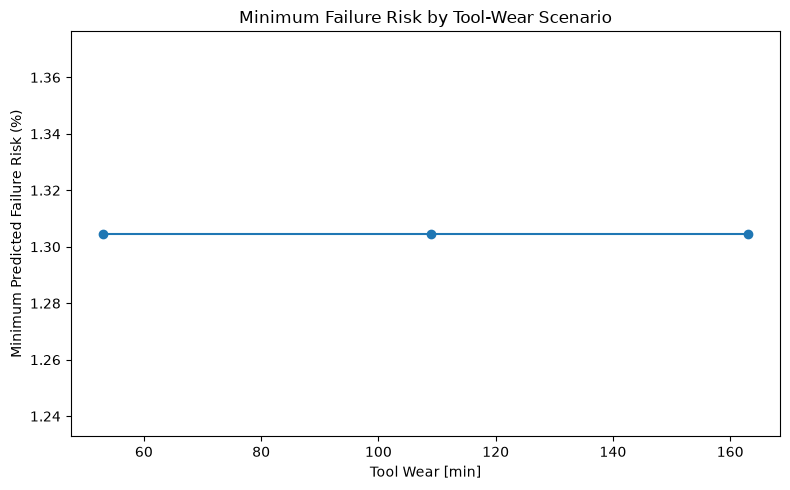

In [33]:
plt.figure(figsize=(8, 5))

plt.plot(
    tool_wear_optimization["Tool Wear [min]"],
    tool_wear_optimization[
        "Predicted Failure Risk (%)"
    ],
    marker="o"
)

plt.xlabel("Tool Wear [min]")
plt.ylabel("Minimum Predicted Failure Risk (%)")

plt.title(
    "Minimum Failure Risk by Tool-Wear Scenario"
)

plt.tight_layout()

plt.savefig(
    "../figures/optimization/"
    "tool_wear_risk_sensitivity.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

## Optimization Summary

The optimization stage translated failure prediction into operational decision support.

First, rotational speed and torque were treated as controllable operating variables. The validated Gradient Boosting model was used as a surrogate failure-risk function, and feasible operating points were searched under a minimum mechanical-power requirement.

This produced a recommended operating region that minimized predicted failure risk while maintaining a specified productivity level.

Because tool wear was identified as one of the strongest predictive features, additional optimization scenarios were evaluated under low, medium, and high tool-wear conditions. This analysis examined whether safe operating adjustments could compensate for progressive equipment degradation.

If minimum achievable failure risk increases with tool wear, the result suggests that operational adjustment alone may eventually become insufficient and that maintenance or tool replacement should be considered.

Finally, a linear-programming extension allocated operating time between low-risk and high-output operating regimes. This demonstrated how machine-learning risk estimates can be incorporated into an operations-research decision model under limited operating time and risk exposure.

The resulting framework therefore integrates:

EDA → SPC → Machine Learning → Failure Diagnosis → Risk-Based Optimization → Linear Programming

The optimization results should be interpreted as model-based decision-support recommendations rather than experimentally verified causal operating policies.

In [34]:
tool_wear_optimization[
    [
        "Scenario",
        "Tool Wear [min]",
        "Optimal RPM",
        "Optimal Torque [Nm]",
        "Mechanical Power [kW]",
        "Predicted Failure Risk (%)"
    ]
].round(6)

,Scenario,Tool Wear [min],Optimal RPM,Optimal Torque [Nm],Mechanical Power [kW],Predicted Failure Risk (%)
0,Low Wear,53.0,1768.338983,41.445763,7.674927,1.304551
1,Medium Wear,109.0,1768.338983,41.445763,7.674927,1.304551
2,High Wear,163.0,1768.338983,41.445763,7.674927,1.304551


In [35]:
tool_wear_optimization["Risk Change (%p)"] = (
    tool_wear_optimization[
        "Predicted Failure Risk (%)"
    ].diff()
)

tool_wear_optimization.round(6)

,Scenario,Tool Wear [min],Optimal RPM,Optimal Torque [Nm],Mechanical Power [kW],Predicted Failure Risk (%),Risk Change (%p)
0,Low Wear,53.0,1768.338983,41.445763,7.674927,1.304551,NaN
1,Medium Wear,109.0,1768.338983,41.445763,7.674927,1.304551,0.0
2,High Wear,163.0,1768.338983,41.445763,7.674927,1.304551,0.0


In [36]:
wear_values = np.linspace(
    train_df["Tool wear [min]"].quantile(0.01),
    train_df["Tool wear [min]"].quantile(0.99),
    100
)

wear_sensitivity_rows = []

for wear in wear_values:

    rpm = best_point["Rotational speed [rpm]"]
    torque = best_point["Torque [Nm]"]

    power = (
        2 * np.pi * rpm * torque
        / 60 / 1000
    )

    row = {
        "Air temperature [K]": base_air_temp,
        "Process temperature [K]": base_process_temp,
        "Rotational speed [rpm]": rpm,
        "Torque [Nm]": torque,
        "Tool wear [min]": wear,
        "Temperature difference [K]": base_temp_diff,
        "Mechanical power [kW]": power,
        "Type": base_type
    }

    row["Torque_SPC_Alarm"] = int(
        torque < sqc_limits["Torque_LCL"]
        or torque > sqc_limits["Torque_UCL"]
    )

    row["Power_SPC_Alarm"] = int(
        power < sqc_limits["Power_LCL"]
        or power > sqc_limits["Power_UCL"]
    )

    row["RPM_SPC_Alarm"] = int(
        rpm < sqc_limits["RPM_LCL"]
        or rpm > sqc_limits["RPM_UCL"]
    )

    wear_sensitivity_rows.append(row)

wear_sensitivity_df = pd.DataFrame(
    wear_sensitivity_rows
)

wear_sensitivity_df["Failure Risk"] = (
    final_model.predict_proba(
        wear_sensitivity_df[feature_set]
    )[:, 1]
)

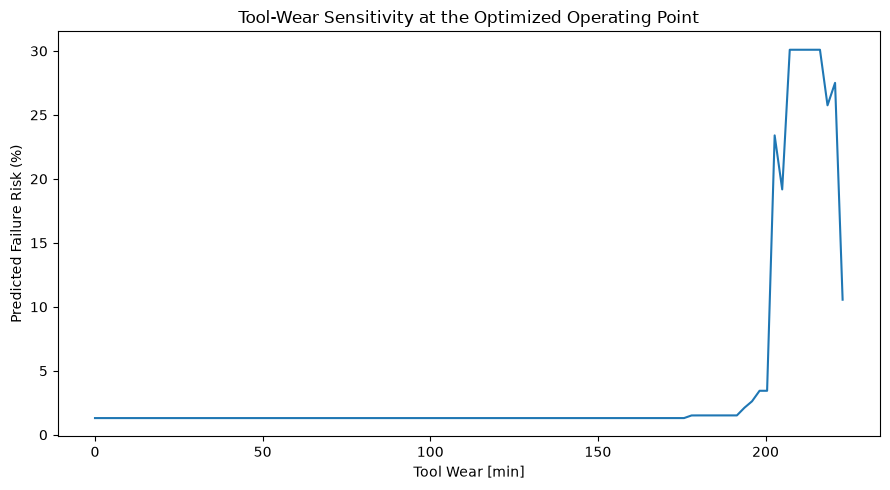

In [37]:
plt.figure(figsize=(9, 5))

plt.plot(
    wear_sensitivity_df["Tool wear [min]"],
    wear_sensitivity_df["Failure Risk"] * 100
)

plt.xlabel("Tool Wear [min]")
plt.ylabel("Predicted Failure Risk (%)")
plt.title(
    "Tool-Wear Sensitivity at the Optimized Operating Point"
)

plt.tight_layout()
plt.show()

In [38]:
risk_thresholds = [0.05, 0.10, 0.20]

threshold_rows = []

for risk_threshold in risk_thresholds:

    risky_points = wear_sensitivity_df[
        wear_sensitivity_df["Failure Risk"]
        >= risk_threshold
    ]

    if len(risky_points) > 0:

        first_point = risky_points.iloc[0]

        threshold_rows.append({
            "Failure Risk Threshold (%)":
                risk_threshold * 100,

            "Approx. Tool Wear Threshold [min]":
                first_point["Tool wear [min]"],

            "Predicted Failure Risk (%)":
                first_point["Failure Risk"] * 100
        })

wear_risk_thresholds = pd.DataFrame(
    threshold_rows
)

wear_risk_thresholds.round(3)

,Failure Risk Threshold (%),Approx. Tool Wear Threshold [min],Predicted Failure Risk (%)
0,5.0,202.727,23.401
1,10.0,202.727,23.401
2,20.0,202.727,23.401


### Tool-Wear Sensitivity at the Optimized Operating Point

A continuous sensitivity analysis was conducted to investigate the effect of tool wear while holding the optimized rotational speed, torque, environmental conditions, and product type constant.

Predicted failure risk remained relatively stable across low-to-moderate tool-wear levels. However, the Gradient Boosting model showed a sharp increase in predicted failure risk once tool wear approached approximately the high-wear region near 200 minutes.

This result explains why the earlier low-, medium-, and high-wear scenarios based on the 25th, 50th, and 75th percentiles produced nearly identical optimized failure risks: all three scenarios remained below the region where the model exhibited a strong nonlinear response to tool wear.

The analysis suggests that tool wear behaves as a threshold-dependent risk indicator rather than as a variable with a simple monotonic linear effect.

This finding is also consistent with the high permutation importance assigned to tool wear and supports the presence of nonlinear relationships learned by the Gradient Boosting model.

However, the identified transition should be interpreted as a model-based predictive threshold rather than a causal or experimentally validated maintenance limit. Irregular predictions in the extreme high-wear region may also reflect sparse observations and tree-based model behavior.